# 00 · Exploración de Multimodal3DIdent

Objetivo: conocer la distribución de los factores generativos, el vocabulario de las descripciones de referencia y fijar los valores discretos que el extractor de atributos deberá reconocer.

Requiere haber corrido `python scripts/build_manifest.py`. Este notebook solo **lee** datos; ninguna figura del informe se genera aquí.

In [6]:
%load_ext autoreload
%autoreload 2
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from vlmfid.data import data_root, read_manifest, disagreement, discrete_text_attributes

ROOT = data_root("base")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
pl_df = read_manifest("test")                     # Parquet tal cual (polars)
df = pd.DataFrame(pl_df.to_dicts())                # pandas para graficar, sin depender de pyarrow
ATTRS = discrete_text_attributes(pl_df)            # latentes de texto discretos detectados
print(len(df), "muestras de test | atributos discretos:", ATTRS)
df.head(3)

10000 muestras de test | atributos discretos: ['object_shape', 'object_xpos', 'object_ypos', 'object_color_name']


,id,image_id,image_path,caption_ref,split,variant,row_idx,object_shape,object_xpos,object_ypos,...,spotlight_pos,spotlight_color,background_color,text_object_shape,text_object_xpos,text_object_ypos,text_object_zpos,text_object_color_name,text_object_color_index,text_text_phrasing
0,base/test/0000,0000,test/images/0000.png,"A hare of ""xkcd:bright yellow green"" color is ...",test,base,0,1,0,1,...,0.028567,0.428084,0.669204,1,0,1,0.0,xkcd:bright yellow green,257,0
1,base/test/0001,0001,test/images/0001.png,"A ""tab:cyan"" dragon is at the mid-center of th...",test,base,1,2,1,1,...,0.148308,0.010805,0.249811,2,1,1,0.0,tab:cyan,139,1
2,base/test/0002,0002,test/images/0002.png,"The bottom-center of the image shows a ""xkcd:g...",test,base,2,6,1,2,...,0.242597,0.426830,0.288410,6,1,2,0.0,xkcd:greenish turquoise,541,2


## Desacuerdo imagen vs texto
Techo alcanzable: si el caption dice un valor distinto del que tiene la imagen, un modelo fiel a la imagen no puede acertar contra ambas verdades a la vez.

In [8]:
disagreement(pl_df)

attribute,rate
str,f64
"""object_shape""",0.0
"""object_xpos""",0.0
"""object_ypos""",0.0
"""object_zpos""",0.0


## Factores discretos del texto
Base de la exactitud por atributo: cada valor debe poder recuperarse desde la descripción.

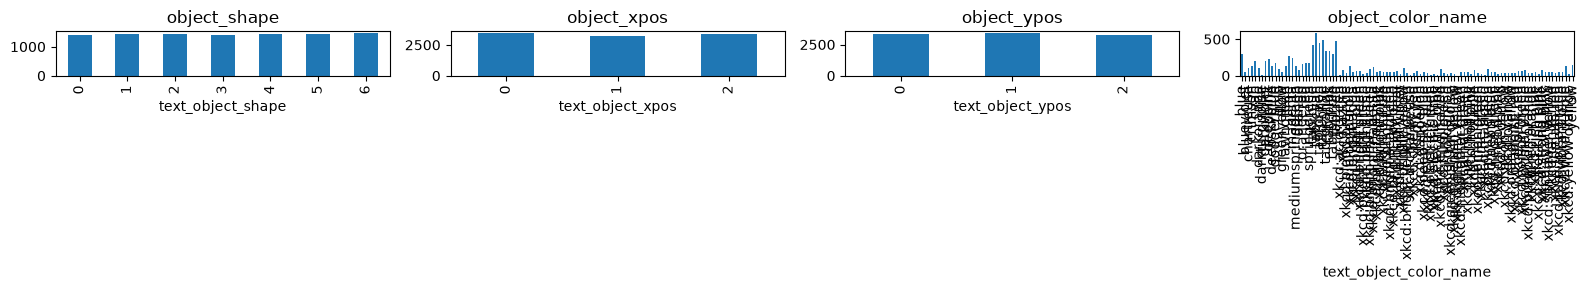

In [9]:
fig, axes = plt.subplots(1, len(ATTRS), figsize=(4 * len(ATTRS), 3))
for ax, f in zip(axes, ATTRS):
    df[f"text_{f}"].value_counts().sort_index().plot.bar(ax=ax, title=f)
plt.tight_layout()

## Factores continuos de la imagen
Ángulos y tonos (hue): no se describen explícitamente en el texto, pero condicionan la dificultad visual.

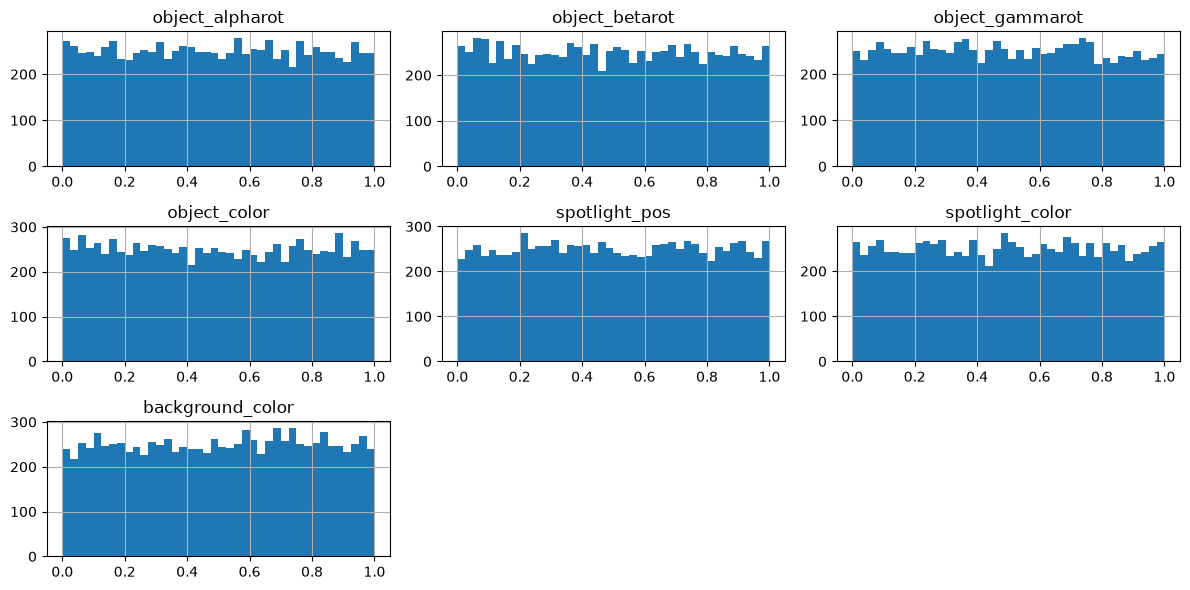

In [10]:
meta = {"id", "image_id", "image_path", "caption_ref", "split", "variant", "row_idx"}
cont = [c for c in df.columns if c not in meta and not c.startswith("text_") and df[c].nunique() > 10]
df[cont].hist(bins=40, figsize=(12, 6)); plt.tight_layout()

## Relación texto ↔ factores
¿Qué palabras aparecen para cada valor? Esto alimenta directamente el diccionario del extractor de atributos.

In [11]:
def words_by_value(factor, top=8):
    out = {}
    for v, g in df.groupby(f"text_{factor}"):
        c = Counter(w.strip('.,').lower() for cap in g.caption_ref for w in cap.split())
        out[v] = [w for w, _ in c.most_common(40) if w not in {"a","the","is","of","in","image","at","an"}][:top]
    return pd.Series(out)

for f in ATTRS:
    print(f"\n== {f}"); print(words_by_value(f).to_string())


== object_shape
0    [teapot, color, visible, positioned, there, ob...
1    [hare, color, picture, visible, positioned, sh...
2    [dragon, color, visible, positioned, picture, ...
3    [cow, color, shows, colored, visible, position...
4    [armadillo, color, shows, colored, picture, th...
5    [horse, color, there, object, form, shows, col...
6    [head, color, visible, positioned, shows, colo...

== object_xpos
0    [color, top-left, bottom-left, mid-left, shows...
1    [color, mid-center, bottom-center, top-center,...
2    [color, mid-right, top-right, bottom-right, pi...

== object_ypos
0    [color, top-left, top-right, top-center, shows...
1    [color, mid-right, mid-left, mid-center, pictu...
2    [color, bottom-left, bottom-center, bottom-rig...

== object_color_name
blue                        ["blue", color, picture, shows, colored, visib...
blueviolet                  ["blueviolet", mid-right, bottom-right, color,...
chartreuse                  ["chartreuse", bottom-left, to

In [12]:
df["n_words"] = df.caption_ref.str.split().str.len()
print(df.n_words.describe())
df.caption_ref.sample(10, random_state=0).tolist()

count    10000.000000
mean        12.911000
std          2.704073
min         10.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         19.000000
Name: n_words, dtype: float64


['A teapot of "tab:blue" color is visible, positioned at the top-right of the image.',
 'At the bottom-left of the picture is a dragon in "orange" color.',
 'The bottom-right of the image shows a "tab:pink" colored horse.',
 'At the top-left of the image, there is a "lawngreen" object in the form of a cow.',
 'A dragon of "tab:cyan" color is visible, positioned at the mid-center of the image.',
 'At the bottom-center of the picture is a cow in "tab:green" color.',
 'A "tab:olive" horse is at the bottom-left of the image.',
 'The top-right of the image shows a "crimson" colored horse.',
 'At the mid-right of the picture is a head in "tab:red" color.',
 'At the top-right of the image, there is a "crimson" object in the form of a dragon.']

## Muestras visuales

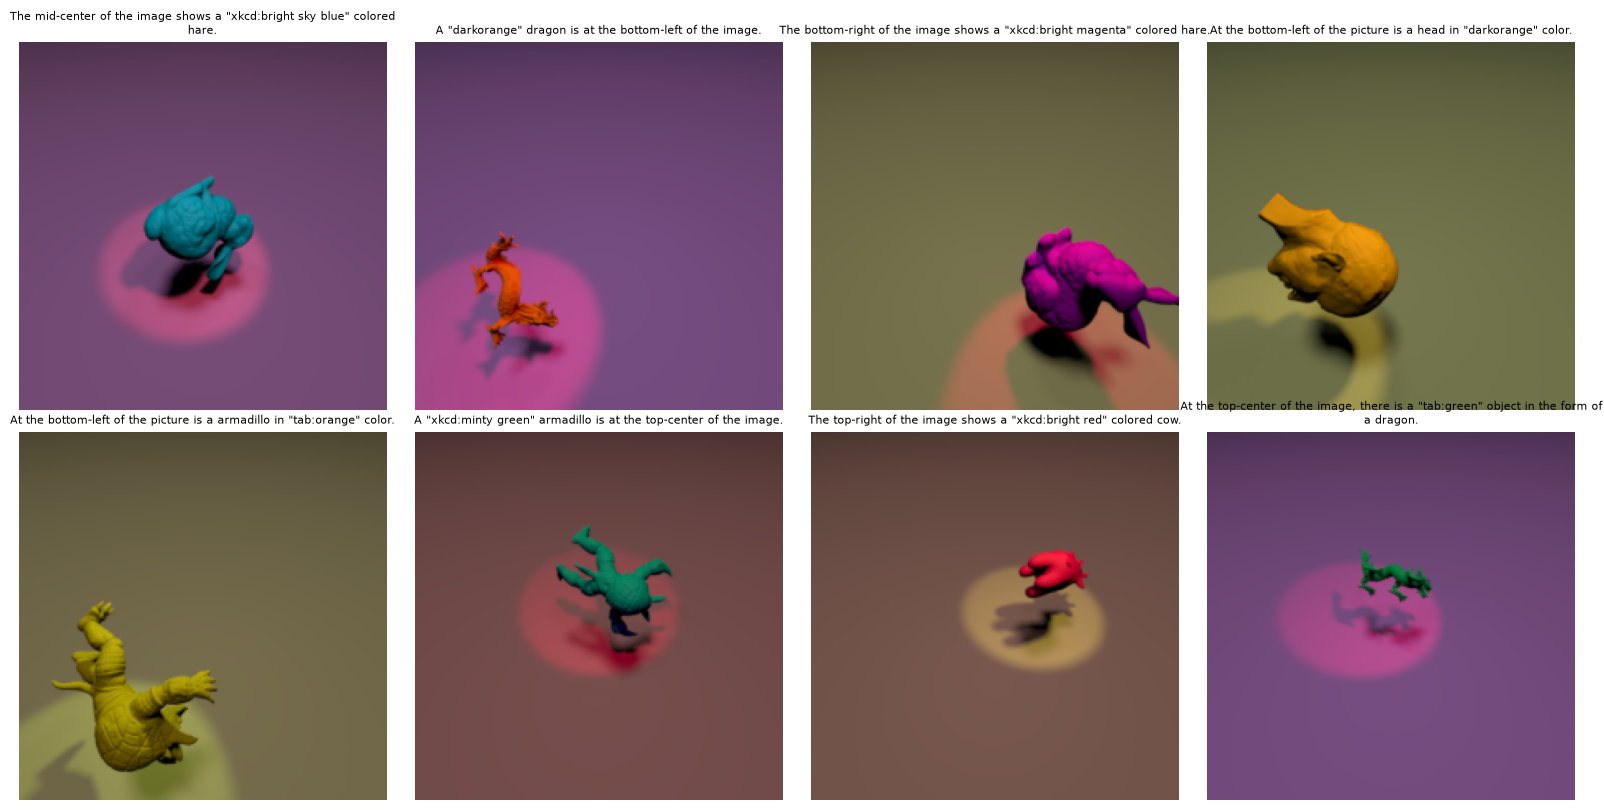

In [13]:
sample = df.sample(8, random_state=1)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(ROOT / r.image_path)); ax.axis("off")
    ax.set_title(r.caption_ref, fontsize=8, wrap=True)
plt.tight_layout()